In [127]:
import time
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

import PCP
import KMean
from dataset import *
from flow_matching import *
from torch.utils.data import DataLoader
from scipy.stats import multivariate_normal
from sklearn.mixture import GaussianMixture

In [128]:
dataset_name = 'Mengze'
data_path = './data/'
n_samples = 30
coverage = 0.9

In [113]:
Y_ens_calib, Y_calib, Y_ens_test, Y_test = get_togo_dataset(dataset_name, data_path)
Y_ens_calib = Y_ens_calib[:,:n_samples,:]
Y_ens_test = Y_ens_test[:,:n_samples,:]

In [114]:
# select 4 data to visualize
ens_visual = Y_ens_test[:10]
test_visual = Y_test[:10]

In [59]:
# KMeans
k_hat = 1
calib_scores = KMean.summary_score_KMeans(Y_ens_calib, Y_calib, k_hat=k_hat)
qt1 = np.quantile(calib_scores, coverage) 
test_scores, test_volumes = KMean.summary_inference_KMeans(Y_ens_test, Y_test, k_hat=k_hat, qt=qt1)
print(f'k_hat: {k_hat}')
print(f'Test Coverage Rate: {np.mean(test_scores < qt1):.6f}')
print(f'Average Volume: {np.mean(test_volumes):.6f}')

k_hat: 1
Test Coverage Rate: 0.852878
Average Volume: 0.006862


In [107]:
# KMeans
k_hat = 2
calib_scores = KMean.summary_score_KMeans(Y_ens_calib, Y_calib, k_hat=k_hat)
qt2 = np.quantile(calib_scores, coverage) 
test_scores, test_volumes = KMean.summary_inference_KMeans(Y_ens_test, Y_test, k_hat=k_hat, qt=qt2)
print(f'k_hat: {k_hat}')
print(f'Test Coverage Rate: {np.mean(test_scores < qt2):.6f}')
print(f'Average Volume: {np.mean(test_volumes):.6f}')

k_hat: 2
Test Coverage Rate: 0.848877
Average Volume: 0.007112


In [61]:
# KMeans
k_hat = 3
calib_scores = KMean.summary_score_KMeans(Y_ens_calib, Y_calib, k_hat=k_hat)
qt3 = np.quantile(calib_scores, coverage) 
test_scores, test_volumes = KMean.summary_inference_KMeans(Y_ens_test, Y_test, k_hat=k_hat, qt=qt3)
print(f'k_hat: {k_hat}')
print(f'Test Coverage Rate: {np.mean(test_scores < qt3):.6f}')
print(f'Average Volume: {np.mean(test_volumes):.6f}')

k_hat: 3
Test Coverage Rate: 0.859649
Average Volume: 0.007189


In [123]:
# PCP
Y_hat = np.concatenate((Y_ens_calib, Y_ens_test), axis=0) # (n_batch, n_samples, dim_y)
Y_cal_test = np.concatenate((Y_calib, Y_test), axis=0).reshape(-1, 1, Y_ens_calib.shape[2]) # (n_batch, 1, dim_y)
# Ranking the samples by their average m-nearest neighbor distances, here we pick m=4.
# Compute pairwise distances between Y and Y_hat_ranked. Each row is a non-conformity score vector.
pcp_vcr = PCP.PCP_VCR(n_sample_K = n_samples,alpha=0.1,y_dim = Y_ens_calib.shape[2])
dist_matrix = pcp_vcr.compute_dist_matrix(Y_cal_test,Y_hat)
pcp_radius = pcp_vcr.pcp_radius(dist_matrix[:len(Y_calib)])
pcp_coverage = pcp_vcr.empirical_coverage(dist_matrix[len(Y_calib):],pcp_radius)
# print(f'PCP Coverage Rate: {pcp_coverage:.6f}')
# pcp_exact_volume1 = PCP.get_coverage_area_overlap(pcp_radius,Y_ens_test)
# print(f'PCP Average Volume1: {np.mean(pcp_exact_volume1):.6f}')
# pcp_exact_volume2 = PCP.get_coverage_area_overlap_grid(pcp_radius,Y_ens_test)
# print(f'PCP Average Volume2: {np.mean(pcp_exact_volume2):.6f}')
# pcp_exact_volume3 = PCP.get_coverage_area_overlap_random(pcp_radius,Y_ens_test)
# print(f'PCP Average Volume3: {np.mean(pcp_exact_volume3):.6f}')


In [129]:
pcp_exact_volume3 = PCP.get_coverage_area_overlap_random(pcp_radius,Y_ens_test, M=500)
print(f'PCP Average Volume3: {np.mean(pcp_exact_volume3):.6f}')
pcp_exact_volume3 = PCP.get_coverage_area_overlap_random(pcp_radius,Y_ens_test, M=1000)
print(f'PCP Average Volume3: {np.mean(pcp_exact_volume3):.6f}')
pcp_exact_volume3 = PCP.get_coverage_area_overlap_random(pcp_radius,Y_ens_test, M=5000)
print(f'PCP Average Volume3: {np.mean(pcp_exact_volume3):.6f}')
pcp_exact_volume3 = PCP.get_coverage_area_overlap_random(pcp_radius,Y_ens_test, M=10000)
print(f'PCP Average Volume3: {np.mean(pcp_exact_volume3):.6f}')
pcp_exact_volume3 = PCP.get_coverage_area_overlap_random(pcp_radius,Y_ens_test, M=15000)
print(f'PCP Average Volume3: {np.mean(pcp_exact_volume3):.6f}')

TypeError: get_coverage_area_overlap_random() got an unexpected keyword argument 'M'

In [100]:
# given k generated data, find prediction set with 90% percent coverage rate on average
def inference(ys, y_hat, k_hat, qt, radius, grid_res=500, eps=1e-6):

    # ys: (N_ens, d)
    # y_hat: (1, d)
    # k_hat: scalar
    # qt: scalar

    d = ys.shape[1]

    if len(ys) != k_hat:
      kmeans = KMeans(n_clusters=k_hat, random_state=0).fit(ys)
      means = kmeans.cluster_centers_
      weights = [np.mean(kmeans.labels_ == i) for i in range(k_hat)]
      covariances = [np.cov(ys[kmeans.labels_ == i].T) + eps * np.eye(d) if weights[i] * len(ys) > 1 else eps * np.eye(d) for i in range(k_hat)]
    else:
      means = ys
      weights = [1/len(ys) for i in range(len(ys))]
      covariances = [eps * np.eye(d) for i in range(len(ys))]

    # Gaussian KDE prediction sets
    buffle0 = (np.max(ys[:,0]) - np.min(ys[:,0])) * 0.4
    buffle1 = (np.max(ys[:,1]) - np.min(ys[:,1])) * 0.4
    buffle = [buffle0, buffle1]
    X_grid = np.linspace(np.min(ys[:,0])-buffle0, np.max(ys[:,0])+buffle0, grid_res)
    Y_grid = np.linspace(np.min(ys[:,1])-buffle1, np.max(ys[:,1])+buffle1, grid_res)
    x, y = np.meshgrid(X_grid, Y_grid)
    pos = np.dstack((x, y))
    dens = np.zeros((k_hat, x.shape[0], x.shape[1]), float)

    for i in range(k_hat):
        dens[i] = - (multivariate_normal.logpdf(pos, mean=means[i], cov=covariances[i], allow_singular=True) + np.log(weights[i]))
    dens = np.min(dens, axis=0)

    dens_new = np.zeros(dens.shape) * np.nan
    dens_new[dens <= qt] = 1
    dens_new[dens > qt] = 0
    km_volume = (np.sum(dens_new)) * (X_grid[1] - X_grid[0]) * (Y_grid[1] - Y_grid[0])
    print('km_volume', km_volume)
    
    grid_data = np.dstack((x, y)).reshape(grid_res**d, d, 1)
    dens_pcp = np.any(np.linalg.norm(grid_data-ys.T,axis=1)<=radius,axis=1).reshape(x.shape[0], x.shape[1])
    coverage_ratio = np.mean(dens_pcp)
    print('coverage_ratio', coverage_ratio)
    volume = np.prod(np.array([np.max(ys[:,i])+buffle[i] for i in range(d)]) - np.array([np.min(ys[:,i])-buffle[i] for i in range(d)]))
    print('volume', volume)
    pcp_volume = coverage_ratio * volume
    print('pcp_volume', pcp_volume)

    # compute score
    scores = []
    for i in range(k_hat):
        score = - (multivariate_normal.logpdf(y_hat, mean=means[i], cov=covariances[i], allow_singular=True) + np.log(weights[i]))
        scores.append(score)
    volume_ = KMean.get_coverage_length_brutal(ys, means, covariances, weights, qt, k_hat, grid_res)
    print('volume_', volume_)
    return min(scores), dens_new, dens_pcp, x, y, km_volume, pcp_volume


def visualize_data(ens_visual, test_visual, k_hat, qt, pcp_radius):


    # Create 4x2 subplot
    fig, axes = plt.subplots(4, figsize=(6, 20))

    # Plot each test case
    for i in range(4):
        ys = ens_visual[i]
        y_hat = test_visual[i]
        km_score, km_dens, km_dens_pcp, km_x, km_y, km_volume, pcp_volume = inference(ys, y_hat, k_hat, qt, pcp_radius)

        # Plot the data points
        buffle0 = (np.max(ys[:,0]) - np.min(ys[:,0])) * 0.2
        buffle1 = (np.max(ys[:,1]) - np.min(ys[:,1])) * 0.2
        axes[i].scatter(ys[:,0], ys[:,1], marker='o', color = 'red', s=10, zorder = 2.5)
        axes[i].scatter(y_hat[0], y_hat[1], marker='^', color = 'orange', s=100, zorder = 2.5)
        axes[i].contour(km_x, km_y, km_dens, [0.5], colors='r')
        axes[i].set_xlim(np.min(km_x)-buffle0/2, np.max(km_x)+buffle0/2)
        axes[i].set_ylim(np.min(km_y)-buffle1/2, np.max(km_y)+buffle1/2)

        # Plot circles of radius pcp_radius around each ensemble point
        for j in range(ys.shape[0]):
            circle = plt.Circle((ys[j,0], ys[j,1]), pcp_radius, fill=False, color='blue', alpha=0.3)
            axes[i].add_patch(circle)
        # pcp_volume = PCP.get_coverage_area_overlap_grid(pcp_radius, ys.reshape(1, -1, 2))[0]

        axes[i].set_title(f'km Volume: {km_volume:.6f}, pcp Volume: {pcp_volume:.6f}')
    # Add super title showing k_hat and method labels
    fig.suptitle(f'k_hat = {k_hat}', fontsize=16, y=0.95)
    plt.show()
    return

km_volume 0.009446086907814894
coverage_ratio 0.4734
volume 0.0218159355018587
pcp_volume 0.010327663866579908
volume_ 0.0085814453338588
km_volume 0.00853463983580637
coverage_ratio 0.416104
volume 0.024065838330281322
pcp_volume 0.010013891592583379
volume_ 0.0083076530166932
km_volume 0.009223887420191992
coverage_ratio 0.46634
volume 0.02151589451240005
pcp_volume 0.010033722246912638
volume_ 0.00848850000541683
km_volume 0.008201686042625868
coverage_ratio 0.537116
volume 0.015617184833444615
pcp_volume 0.008388239849000438
volume_ 0.0064464915012888025


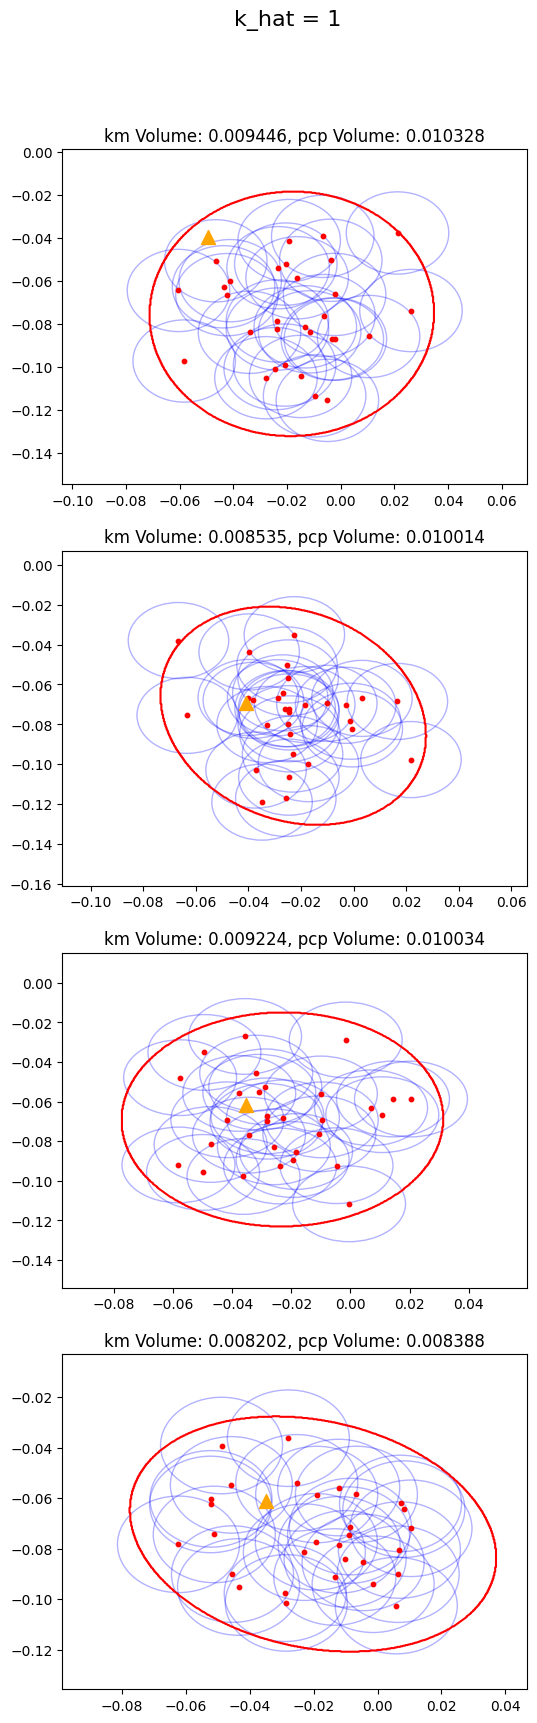

In [101]:
k_hat = 1
visualize_data(ens_visual, test_visual, k_hat, qt1, pcp_radius)

In [104]:
k_hat = 2
visualize_data(ens_visual, test_visual, k_hat, qt2, pcp_radius)

NameError: name 'qt2' is not defined

km_volume 0.007915743524940403
coverage_ratio 0.40668
volume 0.02160599010647971
pcp_volume 0.008786724056503168
volume_ 0.007195141772673237
km_volume 0.007149333263137434
coverage_ratio 0.4787
volume 0.018415516322408863
pcp_volume 0.008815507663537123
volume_ 0.006368341008630467
km_volume 0.00868160843863306
coverage_ratio 0.419256
volume 0.02025646266635479
pcp_volume 0.008492643511645245
volume_ 0.007433992469728645
km_volume 0.009043306031640918
coverage_ratio 0.417604
volume 0.02183048061721156
pcp_volume 0.009116496027670016
volume_ 0.007633136681750768


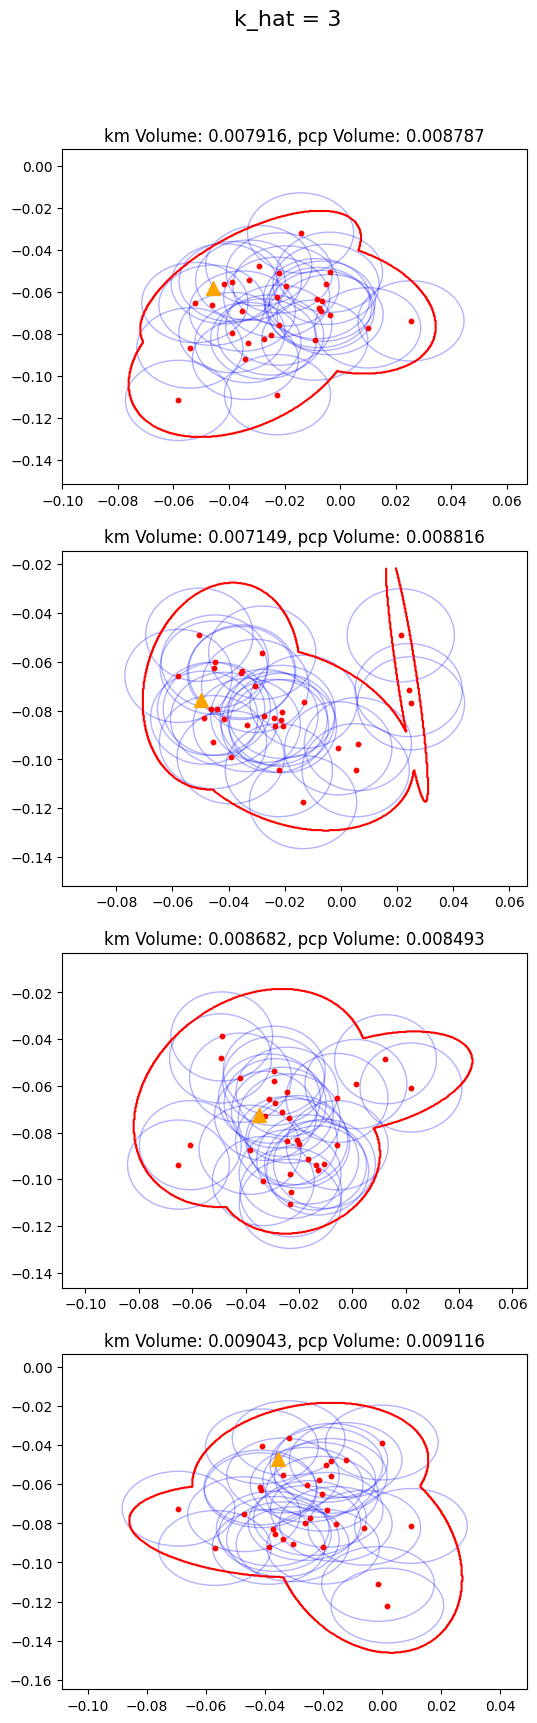

In [103]:
k_hat = 3
visualize_data(ens_visual, test_visual, k_hat, qt3, pcp_radius)

In [2]:
# dataset
dataset_name='s_curve'
# Training parameters
n_epochs=10000
batch_size=1000
hidden_dim=64
timesteps=100
lr=1e-3
# PCP parameters
n_samples=30
coverage=0.9
k_hat=3
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [3]:
X, Y = dataset.get_dataset(dataset_name, base_path=None)
N, d = X.shape[0], X.shape[1]
print(N,d)
train, calib, test = np.split(range(N), [int(.6 * N), int(.8 * N), ])
print(f'train size: {len(train)}, calib size: {len(calib)}, test size: {len(test)}')

5000 1
train size: 3000, calib size: 1000, test size: 1000


data: s_curve
n: 5000
train size: 3000, calib size: 1000, test size: 1000
Epoch 1, Loss: 12.2689
Epoch 2, Loss: 15.6125
Epoch 3, Loss: 14.4992
Epoch 4, Loss: 11.5868
Epoch 5, Loss: 128.6720
Epoch 6, Loss: 15.9420
Epoch 7, Loss: 10.4842
Epoch 8, Loss: 10.6884
Epoch 9, Loss: 11.5510
Epoch 10, Loss: 13.8323
Epoch 11, Loss: 10.5605
Epoch 12, Loss: 15.2075
Epoch 13, Loss: 11.2103
Epoch 14, Loss: 10.0154
Epoch 15, Loss: 30.0239
Epoch 16, Loss: 19.5373
Epoch 17, Loss: 10.2870
Epoch 18, Loss: 12.8817
Epoch 19, Loss: 10.1698
Epoch 20, Loss: 10.7850
Epoch 21, Loss: 12.3974
Epoch 22, Loss: 16.8267
Epoch 23, Loss: 32.5311
Epoch 24, Loss: 12.9618
Epoch 25, Loss: 23.7977
Epoch 26, Loss: 14.8544
Epoch 27, Loss: 8.8523
Epoch 28, Loss: 9.2916
Epoch 29, Loss: 8.2138
Epoch 30, Loss: 11.5075
Epoch 31, Loss: 12.7248
Epoch 32, Loss: 9.9915
Epoch 33, Loss: 9.1125
Epoch 34, Loss: 10.6346
Epoch 35, Loss: 9.3999
Epoch 36, Loss: 12.4598
Epoch 37, Loss: 10.4347
Epoch 38, Loss: 46.8089
Epoch 39, Loss: 9.5654
Epoch

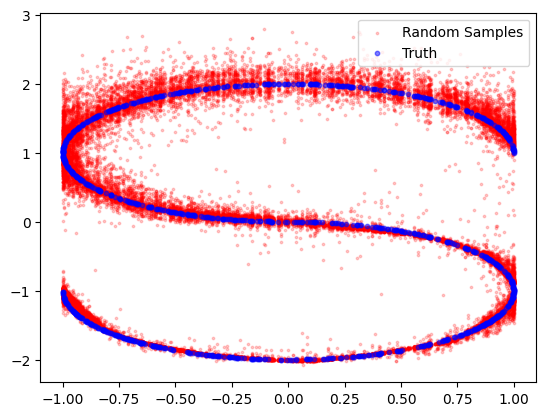

In [9]:
#prepare data
print(f'data: {dataset_name}')

X, Y = get_dataset(dataset_name, base_path=None)
N = X.shape[0]

train, calib, test = np.split(range(N), [int(.6 * N), int(.8 * N), ])
print(f'train size: {len(train)}, calib size: {len(calib)}, test size: {len(test)}')

# Extract train, calib, and test subsets
X_train, Y_train = X[train], Y[train]
X_calib, Y_calib = X[calib], Y[calib]
X_test, Y_test = X[test], Y[test]

# Create Dataset objects
train_dataset = dataset.DatasetTensor(X_train, Y_train)
calib_dataset = dataset.DatasetTensor(X_calib, Y_calib)
test_dataset = dataset.DatasetTensor(X_test, Y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
calib_loader = DataLoader(calib_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Construct Generative Model
linear_alpha = LinearAlpha()
squareroot_beta = SquareRootBeta()
gaussian_path = GaussianPath(linear_alpha, squareroot_beta)

model = FlowMatchingNet(input_dim=Y.shape[1], condition_dim=X.shape[1], hidden_dim=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Train Generative Model
train_flow_matching(model, gaussian_path, train_loader, optimizer, n_epochs, device)

# Sample Generative Model
calib_samples, calib_conditions = generate_samples_for_dataset(model, gaussian_path, calib_loader, n_samples, timesteps, device)
test_samples, test_conditions = generate_samples_for_dataset(model, gaussian_path, test_loader, n_samples, timesteps, device)
# (n_batch, n_samples, dim_y); (n_batch, n_sample, dim_x)

# Validate Results

plt.scatter(
    np.vstack(calib_conditions),
    np.vstack(calib_samples),
    alpha=0.2, s=3, label='Random Samples', color='red'
)

plt.scatter(
    X_calib,
    Y_calib,
    alpha=0.5, s=10, label='Truth', color='blue'
)

plt.legend(loc='upper right')
plt.show()

In [10]:
Y_ens_calib, Y_calib, Y_ens_test, Y_test = calib_samples, Y_calib, test_samples, Y_test
print(f'Y_ens_calib shape: {Y_ens_calib.shape}')
print(f'Y_calib shape: {Y_calib.shape}')
print(f'Y_ens_test shape: {Y_ens_test.shape}')
print(f'Y_test shape: {Y_test.shape}')

np.save(f'data/{dataset_name}/Y_ens_calib.npy', Y_ens_calib)
np.save(f'data/{dataset_name}/Y_calib.npy', Y_calib)
np.save(f'data/{dataset_name}/Y_ens_test.npy', Y_ens_test)
np.save(f'data/{dataset_name}/Y_test.npy', Y_test)


Y_ens_calib shape: (1000, 30, 1)
Y_calib shape: (1000, 1)
Y_ens_test shape: (1000, 30, 1)
Y_test shape: (1000, 1)


In [4]:
Y_calib, Y_test = np.load(f'data/{dataset_name}/Y_calib.npy'), np.load(f'data/{dataset_name}/Y_test.npy')
Y_ens_calib, Y_ens_test = np.load(f'data/{dataset_name}/Y_ens_calib.npy'), np.load(f'data/{dataset_name}/Y_ens_test.npy')
print(f'Y_calib shape: {Y_calib.shape}')
print(f'Y_ens_calib shape: {Y_ens_calib.shape}')
print(f'Y_test shape: {Y_test.shape}')
print(f'Y_ens_test shape: {Y_ens_test.shape}')

Y_calib shape: (1000, 1)
Y_ens_calib shape: (1000, 30, 1)
Y_test shape: (1000, 1)
Y_ens_test shape: (1000, 30, 1)


In [11]:
# function for KMeans
# given k generated data, find prediction set with 1-alpha percent coverage rate on average
def inference(ys, y_hat, k_hat, qt, eps=1e-6, grid_res=100):

    # ys: (N_ens, d)
    # y_hat: (d,)
    # k_hat: scalar
    # qt: scalar

    d = ys.shape[1]

    if len(ys) != k_hat:
      kmeans = KMeans(n_clusters=k_hat, random_state=0).fit(ys)
      means = kmeans.cluster_centers_
      weights = [np.mean(kmeans.labels_ == i) for i in range(k_hat)]
      covariances = [np.cov(ys[kmeans.labels_ == i].T) + eps * np.eye(d) if weights[i] * len(ys) > 1 else eps * np.eye(d) for i in range(k_hat)]
    else:
      means = ys
      weights = [1/len(ys) for i in range(len(ys))]
      covariances = [eps * np.eye(d) for i in range(len(ys))]

    # Gaussian KDE prediction sets
    if d == 2:
        buffle = (np.max(ys[:,0]) - np.min(ys[:,0])) * 0.1
        x, y = np.meshgrid(np.linspace(np.min(ys[:,0])-buffle, np.max(ys[:,0])+buffle, grid_res), np.linspace(np.min(ys[:,1])-buffle, np.max(ys[:,1])+buffle, grid_res))
        pos = np.dstack((x, y))
        dens = np.zeros((k_hat, x.shape[0], x.shape[1]), float)

        for i in range(k_hat):
            dens[i] = - (multivariate_normal.logpdf(pos, mean=means[i], cov=covariances[i], allow_singular=True) + np.log(weights[i]))
        dens = np.min(dens, axis=0)

        dens[dens <= qt] = 1
        dens[dens > qt] = 0

        # compute score
        scores = []
        for i in range(k_hat):
            score = - (multivariate_normal.logpdf(y_hat, mean=means[i], cov=covariances[i], allow_singular=True) + np.log(weights[i]))
            scores.append(score)

        volume = (x.shape[0] * x.shape[1] - np.sum(dens)) * (x[0,1] - x[0,0]) * (y[1,0] - y[0,0])

    elif d == 1:
        buffle = (np.max(ys[:,0]) - np.min(ys[:,0])) * 0.1
        x = np.linspace(np.min(ys[:,0])-buffle, np.max(ys[:,0])+buffle, grid_res)
        dens = np.zeros((k_hat, x.shape[0]), float)
        for i in range(k_hat):
            dens[i] = - (multivariate_normal.logpdf(x, mean=means[i], cov=covariances[i], allow_singular=True) + np.log(weights[i]))
        dens = np.min(dens, axis=0) # min over k_hat----we could also take the summation
        dens[dens <= qt] = 1
        dens[dens > qt] = 0

        # compute score
        scores = []
        for i in range(k_hat):
            score = - (multivariate_normal.logpdf(y_hat, mean=means[i], cov=covariances[i], allow_singular=True) + np.log(weights[i]))
            scores.append(score)

        volume = np.sum(dens) * (x[1] - x[0])
    return min(scores), dens, volume, x

In [7]:
k_hat_list = [1,2,3,4,5,6,7,8,9,10]
qt_list = []
coverage_list = []
volume_list = []
for i in tqdm(range(len(k_hat_list))):
    k_hat = k_hat_list[i]
    calib_scores = KMeans.summary_score(Y_ens_calib, Y_calib, k_hat=k_hat)
    qt = np.quantile(calib_scores, coverage) 
    test_scores, test_volumes = KMeans.summary_inference_kmeans(Y_ens_test, Y_test, k_hat=k_hat, qt=qt)

    #Calculate statistics and save results
    print(f'k_hat: {k_hat}')
    print(f'Test Coverage Rate: {np.mean(test_scores < qt):.2f}')
    print(f'Average Volume: {np.mean(test_volumes):.2f}')
    qt_list.append(qt)
    coverage_list.append(np.mean(test_scores < qt))
    volume_list.append(np.mean(test_volumes))

 10%|█         | 1/10 [00:05<00:53,  5.93s/it]

k_hat: 1
Test Coverage Rate: 0.93
Average Volume: 3.92


 20%|██        | 2/10 [00:19<01:23, 10.40s/it]

k_hat: 2
Test Coverage Rate: 0.91
Average Volume: 2.25


 30%|███       | 3/10 [00:35<01:31, 13.02s/it]

...

k_hat: 8
Test Coverage Rate: 0.90
Average Volume: 0.86


 90%|█████████ | 9/10 [03:01<00:24, 24.67s/it]

k_hat: 9
Test Coverage Rate: 0.90
Average Volume: 0.85


100%|██████████| 10/10 [03:32<00:00, 21.23s/it]

k_hat: 10
Test Coverage Rate: 0.92
Average Volume: 0.87


test_samples shape: (30, 1)
test_point shape: (1,)


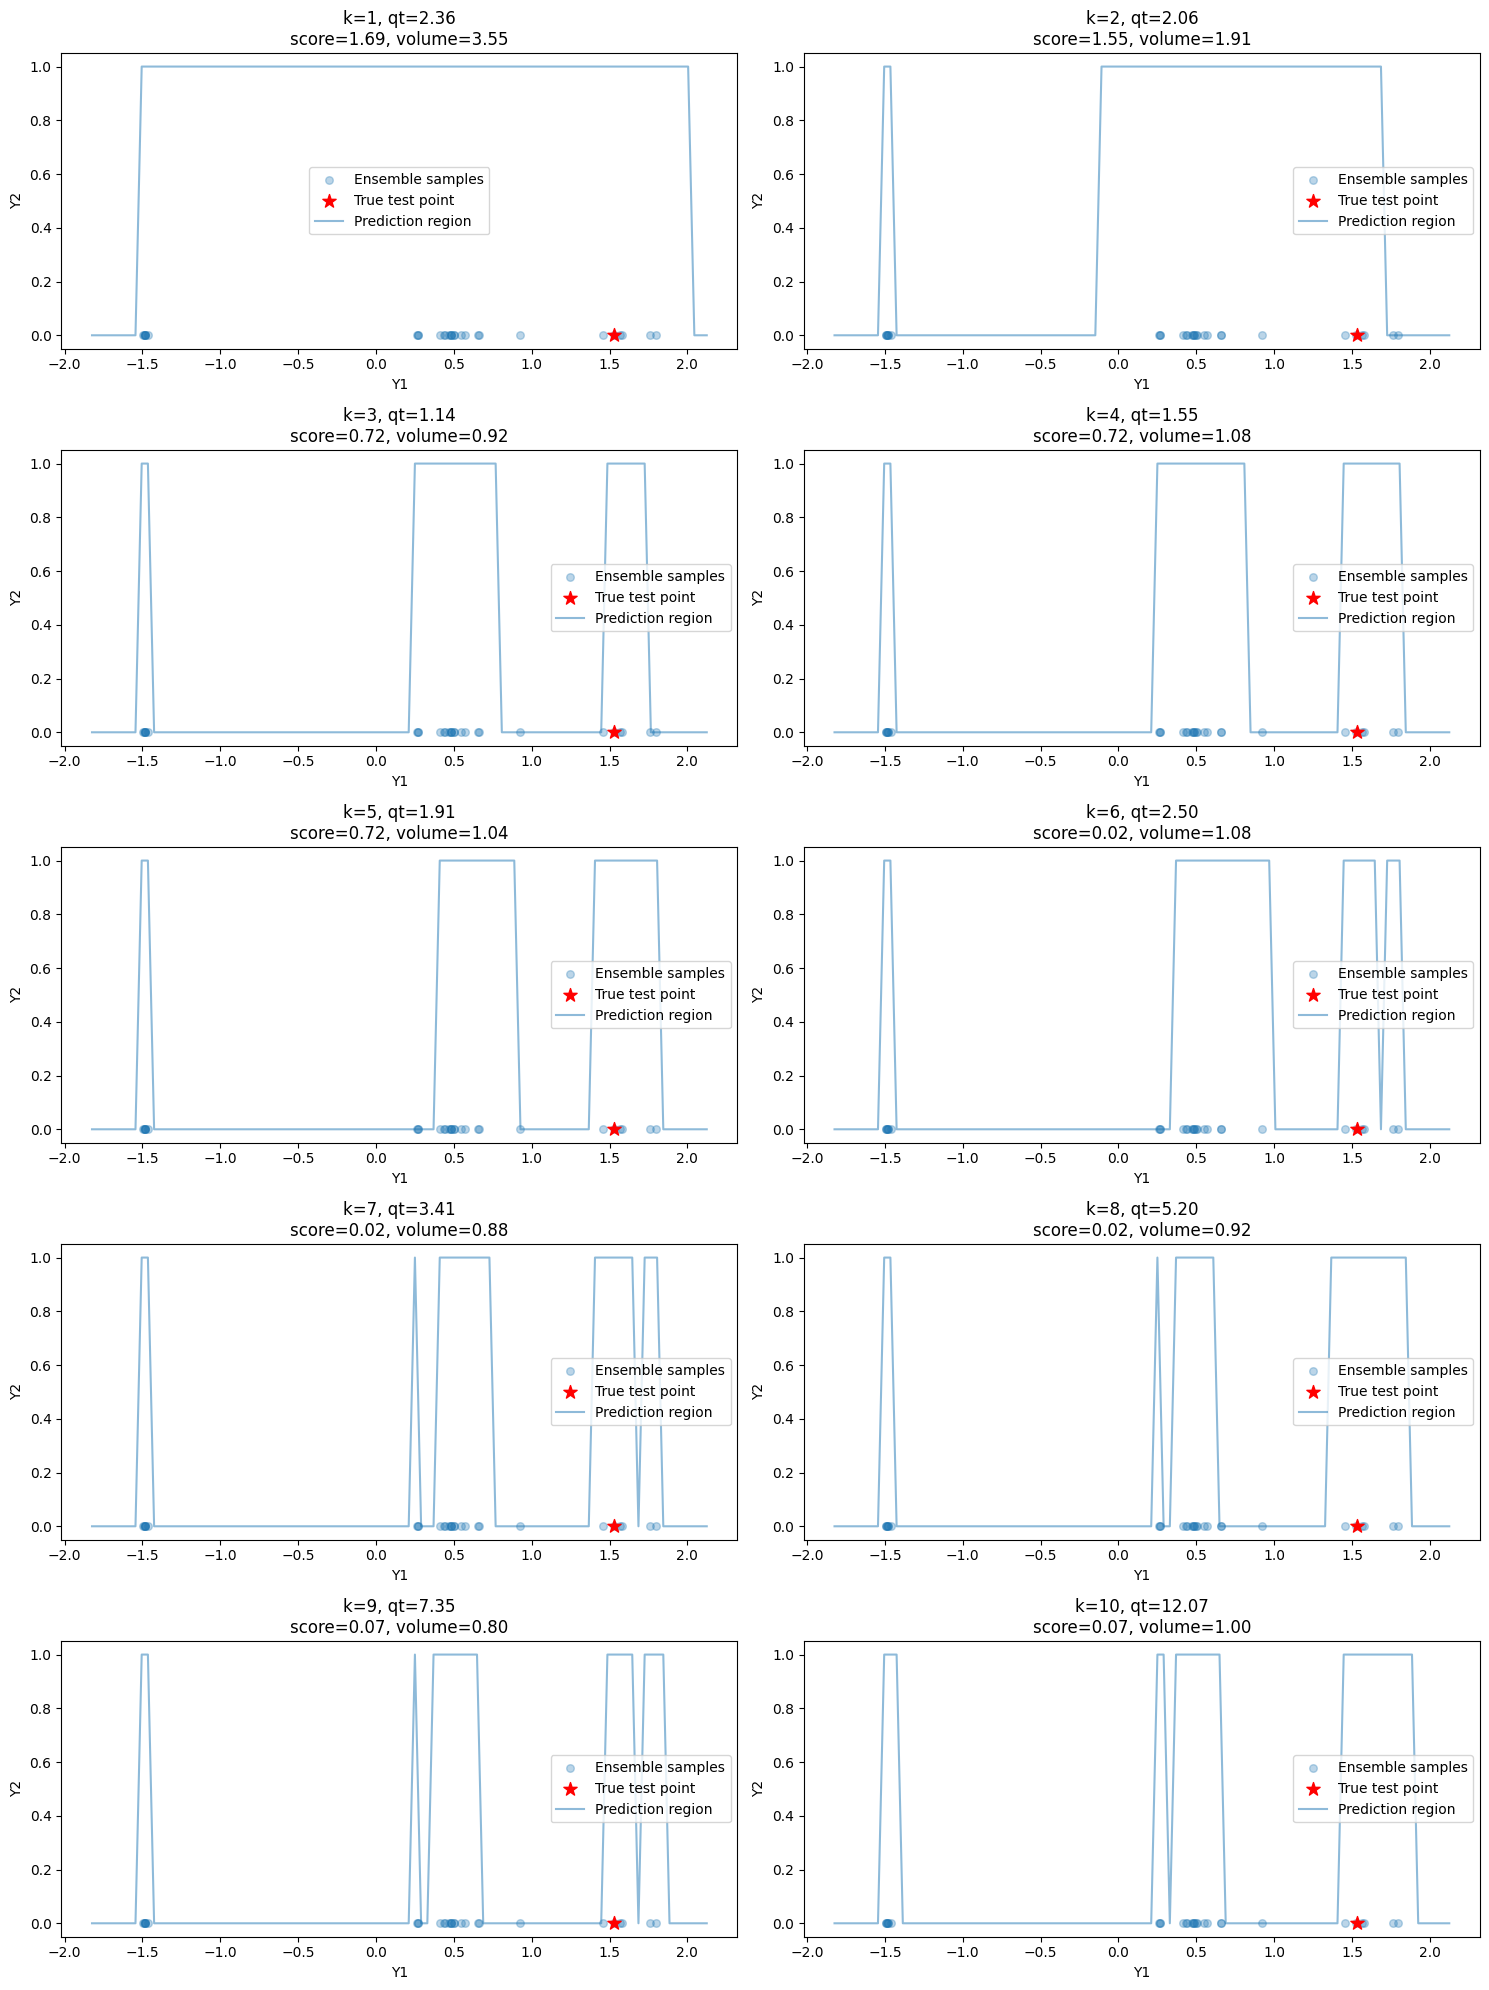

In [12]:
# Visualize results
plt.figure(figsize=(15,20))
idx = 10
test_point = Y_test[idx]
test_samples = Y_ens_test[idx]

print(f'test_samples shape: {test_samples.shape}')
print(f'test_point shape: {test_point.shape}')

for i, (k_hat, qt_val) in enumerate(zip(k_hat_list, qt_list)):
    plt.subplot(5, 2, i+1)
    
    # Get prediction region for this point
    score, dens, volume, x = inference(test_samples, test_point, k_hat=k_hat, qt=qt_val, grid_res=100)
    
    # Plot samples and test point
    plt.scatter(test_samples[:,0], [0]*len(test_samples), alpha=0.3, s=30, label='Ensemble samples')
    plt.scatter(test_point[0], 0, color='red', s=100, marker='*', label='True test point')
    
    # Plot prediction region
    plt.plot(x, dens, label=f'Prediction region', alpha=0.5)
    
    plt.title(f'k={k_hat}, qt={qt_val:.2f}\nscore={score:.2f}, volume={volume:.2f}')
    plt.xlabel('Y1')
    plt.ylabel('Y2')
    plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# pcp
Y_hat = np.concatenate((Y_ens_calib, Y_ens_test), axis=0)
Y_cal_test = np.concatenate((Y_calib, Y_test), axis=0).reshape(-1,1,Y_ens_calib.shape[2])
print(f'Y_hat shape: {Y_hat.shape}')
print(f'Y_cal_test shape: {Y_cal_test.shape}')

# Ranking the samples by their average m-nearest neighbor distances, here we pick m=4.
# Compute pairwise distances between Y and Y_hat_ranked. Each row is a non-conformity score vector.
pcp_vcr = PCP.PCP_VCR(n_sample_K = n_samples,alpha=0.1,y_dim = Y_ens_calib.shape[2])
Y_hat_ranked = pcp_vcr.rank(Y_cal_test,Y_hat,k_neighbor = 4)
dist_matrix = pcp_vcr.compute_dist_matrix(Y_cal_test,Y_hat)
dist_matrix_rank = pcp_vcr.compute_dist_matrix(Y_cal_test,Y_hat_ranked)

Y_hat shape: (2000, 30, 1)
Y_cal_test shape: (2000, 1, 1)


In [15]:
# Approximate algorithm on calibration data: initialize different entries in range(n_sample), and select the approximated solution with the best approximated efficiency (sum of prediction regions, no consideration of overlap).
E_q_list = []
radius_list = []
time_list = []
for pos in tqdm(range(n_samples)):
    start_time = time.time()
    E_q = pcp_vcr.calibrate(dist_matrix_rank[:len(calib),:],num_iter = 300,position=pos)
    end_time = time.time()
    time_list.append(end_time-start_time)
    radius = np.sum(E_q ** pcp_vcr.y_dim)
    E_q_list.append(E_q)
    radius_list.append(radius)


100%|██████████| 30/30 [55:45<00:00, 111.50s/it]  


In [21]:
# Compute the empirical coverage and exact empirical efficiency (with consideration of overlap) on testing data.  
# get_coverage_length_overlap function is used to compute the exact efficiency of the coverage set, but this is only computable in 1-dim data. For higher dimensions, there is no analytical solution other than Monte Carlo. 
pcp_vcr_radius = E_q_list[np.argmin(radius_list)]
emp_coverage = pcp_vcr.empirical_coverage(dist_matrix_rank[len(calib):,:],pcp_vcr_radius)
print(f"PCP-VCR empirical coverage: {emp_coverage:.3f}")
rank_pcp_exact_length = PCP.get_coverage_length_overlap(pcp_vcr_radius,Y_hat_ranked[len(calib):])
print(f"PCP-VCR empirical efficiency: {np.mean(rank_pcp_exact_length):.3f}")

PCP-VCR empirical coverage: 0.898
PCP-VCR empirical efficiency: 0.888


In [20]:
# Compare with results of PCP.  
pcp_radius = pcp_vcr.pcp_radius(dist_matrix[:len(calib)])
pcp_coverage = pcp_vcr.empirical_coverage(dist_matrix[len(calib):],pcp_radius)
pcp_exact_length = PCP.get_coverage_length_overlap(pcp_radius,Y_hat[len(calib):])
print(f"PCP empirical coverage: {pcp_coverage:.3f}")
print(f"PCP empirical efficiency: {np.mean(pcp_exact_length):.3f}")

PCP empirical coverage: 0.927
PCP empirical efficiency: 0.847


In [18]:
pcp_radius, pcp_vcr_radius

(0.03706312801097966,
 array([3.45777791e-03, 1.62116784e-04, 6.27487941e-03, 1.16796479e-01,
        6.39661763e-03, 7.36850967e-03, 8.47112133e-04, 3.06203813e-03,
        8.47893799e-03, 4.95552720e-03, 8.71335021e-03, 8.23254783e-03,
        1.08577570e-02, 1.78071293e-02, 1.42199394e-02, 1.04548765e-02,
        1.44802920e-02, 2.72286146e-02, 3.12769912e-02, 1.78176684e-02,
        1.28437323e-01, 5.11764812e-03, 2.43877249e-03, 1.89728829e-03,
        2.01161481e-01, 1.37014453e-02, 1.59688631e-02, 1.02935830e-02,
        5.80158699e-03, 1.32887682e-03]))